In [2]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 데이터 불러오기
y_it = pd.read_csv('Y_it_for_regression.csv')
doge_it = pd.read_csv('doge_intensity_weighted_average_full.csv')
x_it = pd.read_csv('X_it_for_regression.csv')

# 2. 컬럼 정리
doge_it = doge_it.rename(columns={'state_name': 'State', 'DOGE_Intensity_WeightedAverage': 'DOGE_Intensity'})

# 3. doge_it에 Quarter 복제
quarters = y_it['Quarter'].unique()
doge_it['key'] = 1
quarters_df = pd.DataFrame({'Quarter': quarters})
quarters_df['key'] = 1
doge_it = pd.merge(doge_it, quarters_df, on='key').drop('key', axis=1)

# 4. y_it에 State 복제
states = doge_it['State'].unique()
y_it['key'] = 1
states_df = pd.DataFrame({'State': states})
states_df['key'] = 1
y_it = pd.merge(y_it, states_df, on='key').drop('key', axis=1)

# 5. Merge
df = y_it.merge(doge_it[['State', 'Quarter', 'DOGE_Intensity']], on=['State', 'Quarter'])
df = df.merge(x_it, on='State')

# 6. 고정효과 변수들 타입 설정
df['State'] = df['State'].astype('category')
df['Quarter'] = df['Quarter'].astype('category')

# 7. 독립변수 리스트 설정
independent_vars = ['DOGE_Intensity'] + [col for col in df.columns if col not in ['State', 'Quarter', 'Y_it', 'DOGE_Intensity']]

def safe_variable(var):
    if not var.isidentifier():
        return f'Q("{var}")'  # 변수명을 문자열로 묶어서 Q() 처리
    else:
        return var

# 8. 회귀식 설정
formula = 'Y_it ~ ' + ' + '.join(
    [safe_variable(var) for var in independent_vars]
) + ' + C(State) + C(Quarter)'


# 9. 회귀분석 실행
model = smf.ols(formula=formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['State']})

# 10. 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   Y_it   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.742e+36
Date:                Thu, 08 May 2025   Prob (F-statistic):               0.00
Time:                        23:12:12   Log-Likelihood:                 29316.
No. Observations:                1020   AIC:                        -5.849e+04
Df Residuals:                     950   BIC:                        -5.815e+04
Df Model:                          69                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 92, but rank is 51
  warnings.warn('covariance of constraints does not have full '


In [3]:
print(doge_it.head())


     State  federal_workers  share_of_employment  \
0  Alabama            61913             0.027286   
1  Alabama            61913             0.027286   
2  Alabama            61913             0.027286   
3  Alabama            61913             0.027286   
4  Alabama            61913             0.027286   

   DOGE_Intensity_EmploymentBased  DOGE_Intensity_BudgetBased  DOGE_Intensity  \
0                        0.003274                    0.000709        0.001992   
1                        0.003274                    0.000709        0.001992   
2                        0.003274                    0.000709        0.001992   
3                        0.003274                    0.000709        0.001992   
4                        0.003274                    0.000709        0.001992   

  Quarter  
0  2020Q2  
1  2020Q3  
2  2020Q4  
3  2021Q1  
4  2021Q2  


In [4]:
print(y_it.columns)

Index(['Quarter', 'Y_it', 'State'], dtype='object')


In [5]:
import pandas as pd
import statsmodels.api as sm

# (1) 데이터 불러오기
df_y = pd.read_csv('Y_it_multiplicative_adjusted_full.csv', parse_dates=['Week'])
df_x = pd.read_csv('X_it_for_regression.csv')
df_doge = pd.read_csv('doge_intensity_weighted_average_full.csv')

# (2) 컬럼 이름 정리
df_doge = df_doge.rename(columns={'state_name': 'State'})

# (3) 데이터 병합
df_merged = df_y.merge(df_doge, on='State', how='left')
df_merged = df_merged.merge(df_x, on='State', how='left')

# (4) 2022~2025년 데이터만 필터링
df_merged = df_merged[(df_merged['Week'] >= '2022-01-01') & (df_merged['Week'] <= '2025-12-31')]

# (5) POST 더미 변수 생성
df_merged['POST'] = (df_merged['Week'] >= pd.to_datetime('2025-01-01')).astype(int)

# (6) DOGE_Intensity × POST 상호작용항 생성
df_merged['DOGE_Intensity_POST'] = df_merged['DOGE_Intensity_EmploymentBased'] * df_merged['POST']

# (7) 독립변수 및 종속변수 설정
from sklearn.decomposition import PCA

# 산업구조 변수만 추출
industry_cols = [col for col in df_x.columns if col not in ['State', 'Population_Density', 'College_Educated_Share']]
X_industry = df_merged[industry_cols]

# 결측치 처리 (필요하면)
X_industry = X_industry.fillna(0)

# PCA 2개 성분으로 축소
pca = PCA(n_components=2)
industry_pca = pca.fit_transform(X_industry)

# DataFrame으로 합치기
df_merged['Industry_PC1'] = industry_pca[:, 0]
df_merged['Industry_PC2'] = industry_pca[:, 1]

# 회귀 독립변수 설정
indep_vars = [
    'POST',
    'DOGE_Intensity_POST',
    'Population_Density',
    'College_Educated_Share',
    'Industry_PC1',
    'Industry_PC2'
]


X = df_merged[indep_vars]
X = sm.add_constant(X)
y = df_merged['Adjusted Initial Claims']
groups = df_merged['State']

# (8) missing='drop' 처리
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]
groups = groups.loc[valid_idx]


# (9) 회귀 실행 (State별 클러스터 표준오차)
model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})

# 결과 출력
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.178
Model:                                 OLS   Adj. R-squared:                  0.178
Method:                      Least Squares   F-statistic:                     3.010
Date:                     Thu, 08 May 2025   Prob (F-statistic):             0.0137
Time:                             23:12:13   Log-Likelihood:                -88975.
No. Observations:                     8772   AIC:                         1.780e+05
Df Residuals:                         8765   BIC:                         1.780e+05
Df Model:                                6                                         
Covariance Type:                   cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1.509e+04   5400.250      2.795      0.005    4506.913    2.57e+04
POST                    1466.9876   1018.135      1.441      0.150    -528.520    3462.495
DOGE_Intensity_POST    -5.132e+05   3.87e+05     -1.328      0.184   -1.27e+06    2.44e+05
Population_Density        -0.7556      0.656     -1.152      0.249      -2.041       0.530
College_Educated_Share -2.396e+04   1.16e+04     -2.059      0.040   -4.68e+04   -1150.991
Industry_PC1           -3.477e+05   1.62e+05     -2.144      0.032   -6.66e+05   -2.98e+04
Industry_PC2            9.679e+04   4.64e+04      2.085      0.037    5795.837    1.88e+05
==============================================================================
Omnibus:                     7073.449   Durbin-Watson:                   0.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           158343.399
Skew:                           3.837   Prob(JB):                         0.00
Kurtosis:                      22.348   Cond. No.                     2.15e+06
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 2.15e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# (1) PCA로 Industry_PC1, Industry_PC2 만들기
industry_cols = [col for col in df_x.columns if col not in ['State', 'Population_Density', 'College_Educated_Share']]
X_industry = df_merged[industry_cols].fillna(0)

pca = PCA(n_components=2)
industry_pca = pca.fit_transform(X_industry)

df_merged['Industry_PC1'] = industry_pca[:, 0]
df_merged['Industry_PC2'] = industry_pca[:, 1]

# (2) 스케일링
to_scale = ['Population_Density', 'College_Educated_Share', 'Industry_PC1', 'Industry_PC2']
scaler = StandardScaler()
df_merged_scaled = df_merged.copy()
df_merged_scaled[to_scale] = scaler.fit_transform(df_merged_scaled[to_scale])

# (3) 독립변수 설정
indep_vars = [
    'POST',
    'DOGE_Intensity_POST',
    'Population_Density',
    'College_Educated_Share',
    'Industry_PC1',
    'Industry_PC2'
]

X = df_merged_scaled[indep_vars]
X = sm.add_constant(X)
y = df_merged_scaled['Adjusted Initial Claims']
groups = df_merged_scaled['State']

# (4) 결측치 처리
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]
groups = groups.loc[valid_idx]

# (5) 회귀 실행
model = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})

# 결과 출력
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.178
Model:                                 OLS   Adj. R-squared:                  0.178
Method:                      Least Squares   F-statistic:                     3.010
Date:                     Thu, 08 May 2025   Prob (F-statistic):             0.0137
Time:                             23:12:13   Log-Likelihood:                -88975.
No. Observations:                     8772   AIC:                         1.780e+05
Df Residuals:                         8765   BIC:                         1.780e+05
Df Model:                                6                                         
Covariance Type:                   cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   6316.4226   1679.944      3.760      0.000    3023.793    9609.052
POST                    1466.9876   1018.135      1.441      0.150    -528.520    3462.495
DOGE_Intensity_POST    -5.132e+05   3.87e+05     -1.328      0.184   -1.27e+06    2.44e+05
Population_Density     -1042.1030    904.546     -1.152      0.249   -2814.981     730.775
College_Educated_Share -1705.0390    828.152     -2.059      0.040   -3328.187     -81.891
Industry_PC1           -1.049e+04   4891.855     -2.144      0.032   -2.01e+04    -898.161
Industry_PC2            2301.8438   1104.105      2.085      0.037     137.839    4465.849
==============================================================================
Omnibus:                     7073.449   Durbin-Watson:                   0.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           158343.399
Skew:                           3.837   Prob(JB):                         0.00
Kurtosis:                      22.348   Cond. No.                     2.19e+03
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 2.19e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [10]:
# NAICS 코드 목록 정의
naics_cols = [
     '11', '21', '22', '23', '31-33', '42', '44-45', '48-49',
    '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '99'
]

# PCA component별 loading 값 출력
for i, component in enumerate(pca.components_):
    print(f"\nPC{i+1} loadings:")
    for name, weight in zip(naics_cols, component):
        print(f"  {name}: {weight:.3f}")



PC1 loadings:
  11: 0.008
  21: 0.023
  22: 0.020
  23: 0.171
  31-33: 0.500
  42: 0.145
  44-45: 0.461
  48-49: 0.146
  51: 0.016
  52: 0.133
  53: 0.028
  54: 0.009
  55: 0.056
  56: 0.122
  61: 0.016
  62: 0.574
  71: 0.040
  72: 0.307
  81: 0.055
  99: 0.000

PC2 loadings:
  11: 0.005
  21: -0.053
  22: -0.008
  23: -0.124
  31-33: 0.645
  42: 0.038
  44-45: -0.078
  48-49: 0.020
  51: -0.111
  52: -0.041
  53: -0.078
  54: -0.519
  55: 0.007
  56: -0.149
  61: -0.180
  62: -0.200
  71: -0.070
  72: -0.351
  81: -0.214
  99: -0.001


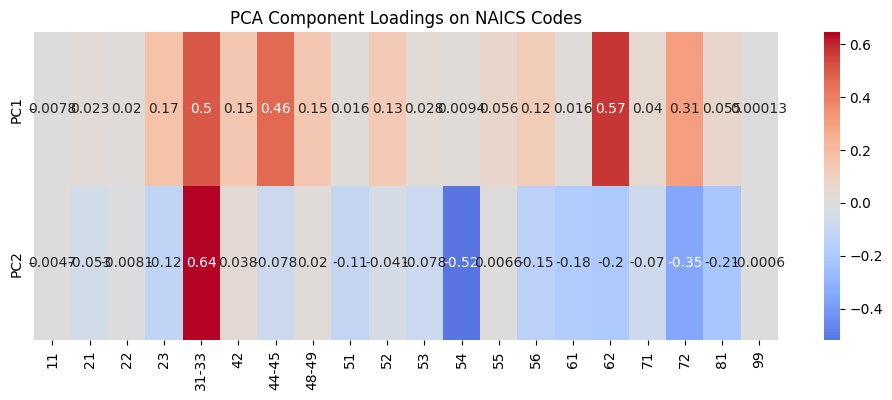

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAICS 코드 목록 정의
naics_cols = [
     '11', '21', '22', '23', '31-33', '42', '44-45', '48-49',
    '51', '52', '53', '54', '55', '56', '61', '62', '71', '72', '81', '99'
]

# PCA components DataFrame 생성
pca_loadings = pd.DataFrame(pca.components_, columns=naics_cols, index=['PC1', 'PC2'])

# 히트맵 그리기
plt.figure(figsize=(12, 4))
sns.heatmap(pca_loadings, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Component Loadings on NAICS Codes')
plt.show()


In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산용 X (상수 포함)
X_vif = X.copy()

vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)


                 Variable       VIF
0                   const  1.780376
1                    POST  2.507413
2     DOGE_Intensity_POST  2.573748
3      Population_Density  2.353514
4  College_Educated_Share  1.701284
5            Industry_PC1  3.453822
6            Industry_PC2  2.753117


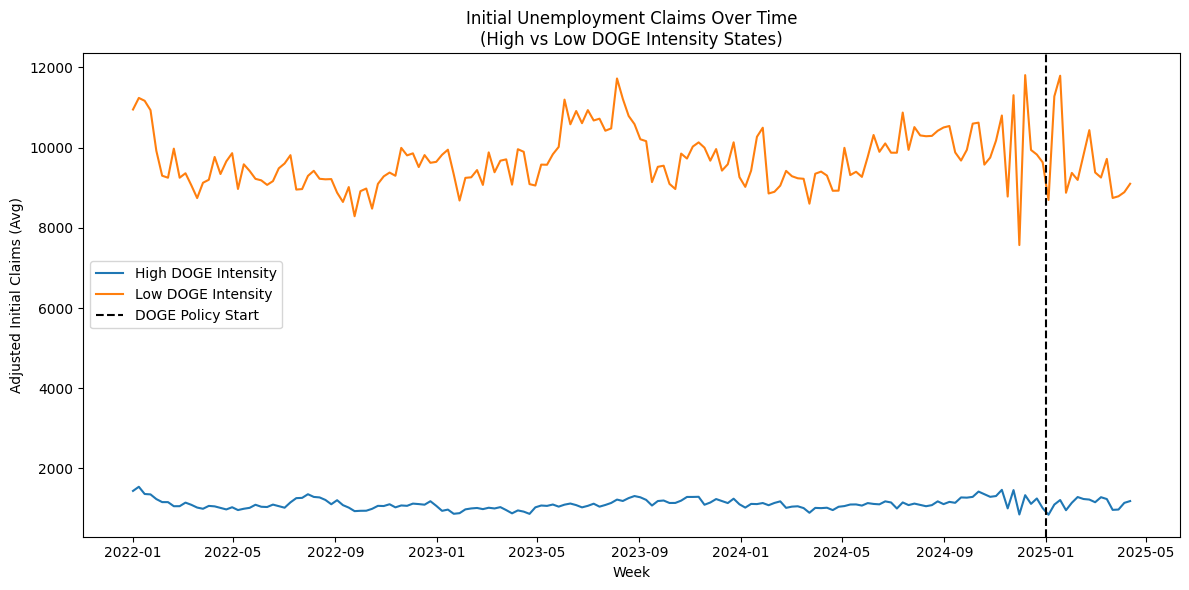

In [ ]:
import matplotlib.pyplot as plt

# (1) DOGE Intensity 상위 25%, 하위 25% 그룹 나누기
q75 = df_merged['DOGE_Intensity_EmploymentBased'].quantile(0.75)
q25 = df_merged['DOGE_Intensity_EmploymentBased'].quantile(0.25)

df_merged['Group'] = 'Middle'
df_merged.loc[df_merged['DOGE_Intensity_EmploymentBased'] >= q75, 'Group'] = 'High'
df_merged.loc[df_merged['DOGE_Intensity_EmploymentBased'] <= q25, 'Group'] = 'Low'

# (2) 주차별 그룹 평균 계산
df_plot = df_merged[df_merged['Group'].isin(['High', 'Low'])]
df_plot = df_plot.groupby(['Week', 'Group'])['Adjusted Initial Claims'].mean().reset_index()

# (3) 시각화
plt.figure(figsize=(12, 6))
for group in ['High', 'Low']:
    subset = df_plot[df_plot['Group'] == group]
    plt.plot(subset['Week'], subset['Adjusted Initial Claims'], label=f'{group} DOGE Intensity')

# 정책 시행 시점 표시
plt.axvline(pd.to_datetime('2025-01-01'), color='black', linestyle='--', label='DOGE Policy Start')

plt.title('Initial Unemployment Claims Over Time\n(High vs Low DOGE Intensity States)')
plt.xlabel('Week')
plt.ylabel('Adjusted Initial Claims (Avg)')
plt.legend()
plt.tight_layout()
plt.show()


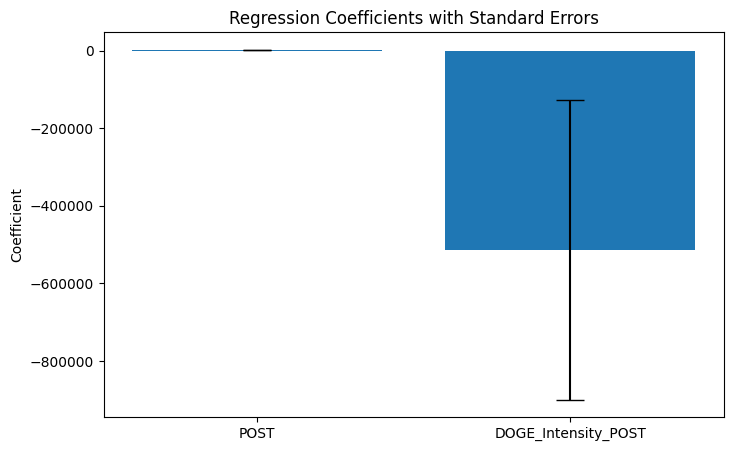

In [ ]:
import matplotlib.pyplot as plt

# (1) 회귀 결과에서 계수, 표준오차 추출
coef_df = model.summary2().tables[1].reset_index()
coef_df = coef_df[coef_df['index'].isin(['POST', 'DOGE_Intensity_POST'])]

# (2) 데이터 준비
x_labels = coef_df['index']
coefs = coef_df['Coef.']
errors = coef_df['Std.Err.']

# (3) 막대그래프 + 에러바
plt.figure(figsize=(8, 5))
plt.bar(x_labels, coefs, yerr=errors, capsize=10)
plt.title('Regression Coefficients with Standard Errors')
plt.ylabel('Coefficient')
plt.show()


In [ ]:
# (8) missing='drop' 수정 버전
full_data = pd.concat([X, y, groups], axis=1).dropna()
X = full_data[X.columns]
y = full_data['Adjusted Initial Claims']
groups = full_data['State']

# (9) 회귀 실행
model_pca = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})

# 결과 출력
model_pca.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                              
===================================================================================
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.178
Model:                                 OLS   Adj. R-squared:                  0.178
Method:                      Least Squares   F-statistic:                     3.010
Date:                     Sat, 03 May 2025   Prob (F-statistic):             0.0137
Time:                             18:02:19   Log-Likelihood:                -88975.
No. Observations:                     8772   AIC:                         1.780e+05
Df Residuals:                         8765   BIC:                         1.780e+05
Df Model:                                6                                         
Covariance Type:                   cluster                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   6316.4226   1679.944      3.760      0.000    3023.793    9609.052
POST                    1466.9876   1018.135      1.441      0.150    -528.520    3462.495
DOGE_Intensity_POST    -5.132e+05   3.87e+05     -1.328      0.184   -1.27e+06    2.44e+05
Population_Density     -1042.1030    904.546     -1.152      0.249   -2814.981     730.775
College_Educated_Share -1705.0390    828.152     -2.059      0.040   -3328.187     -81.891
Industry_PC1           -1.049e+04   4891.855     -2.144      0.032   -2.01e+04    -898.161
Industry_PC2            2301.8438   1104.105      2.085      0.037     137.839    4465.849
==============================================================================
Omnibus:                     7073.449   Durbin-Watson:                   0.048
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           158343.399
Skew:                           3.837   Prob(JB):                         0.00
Kurtosis:                      22.348   Cond. No.                     2.19e+03
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 2.19e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
import pandas as pd
df_doge=pd.read_csv('doge_intensity_weighted_average_full.csv')
df_doge=df_doge.rename(columns={'state_name': 'State'})

# DOGE_Intensity_EmploymentBased 기준 상위 10개 주 추출
top10_doge_states = df_doge[['State', 'DOGE_Intensity_WeightedAverage']].sort_values(
    by='DOGE_Intensity_WeightedAverage', ascending=False).head(10)

print(top10_doge_states)

                   State  DOGE_Intensity_WeightedAverage
8   District of Columbia                        0.009636
20              Maryland                        0.005265
46              Virginia                        0.003982
31            New Mexico                        0.003504
1                 Alaska                        0.003285
11                Hawaii                        0.003249
36              Oklahoma                        0.002497
48         West Virginia                        0.002227
50               Wyoming                        0.002117
26               Montana                        0.002080


In [4]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# (1) 데이터 불러오기
df_y = pd.read_csv('Y_it_multiplicative_adjusted_full.csv', parse_dates=['Week'])
df_x = pd.read_csv('X_it_for_regression.csv')
df_doge = pd.read_csv('doge_intensity_weighted_average_full.csv')
df_doge = df_doge.rename(columns={'state_name': 'State'})

# (2) DOGE Intensity 상위 10개 주 추출
top10_states = df_doge[['State', 'DOGE_Intensity_WeightedAverage']].sort_values(
    by='DOGE_Intensity_WeightedAverage', ascending=False).head(10)['State'].tolist()

# (3) 데이터 병합
df_merged = df_y.merge(df_doge, on='State', how='left')
df_merged = df_merged.merge(df_x, on='State', how='left')

# (4) 필터링 및 POST 생성
df_merged = df_merged[(df_merged['Week'] >= '2022-01-01') & (df_merged['Week'] <= '2025-12-31')]
df_merged['POST'] = (df_merged['Week'] >= pd.to_datetime('2025-01-01')).astype(int)

# (5) 산업구조 PCA
industry_cols = [col for col in df_x.columns if col not in ['State', 'Population_Density', 'College_Educated_Share']]
X_industry = df_merged[industry_cols].fillna(0)
pca = PCA(n_components=2)
industry_pca = pca.fit_transform(X_industry)
df_merged['Industry_PC1'] = industry_pca[:, 0]
df_merged['Industry_PC2'] = industry_pca[:, 1]

# (6) 상호작용항 생성 및 중심화
df_merged['DOGE_Intensity_c'] = df_merged['DOGE_Intensity_WeightedAverage'] - df_merged['DOGE_Intensity_WeightedAverage'].mean()
df_merged['POST_c'] = df_merged['POST'] - df_merged['POST'].mean()
df_merged['DOGE_Intensity_POST_c'] = df_merged['DOGE_Intensity_c'] * df_merged['POST_c']

# (7) 상위 10개 주 필터링
df_top10 = df_merged[df_merged['State'].isin(top10_states)]

# (8) 표준화
scaler = StandardScaler()
to_scale = ['Population_Density', 'College_Educated_Share', 'Industry_PC1', 'Industry_PC2', 'DOGE_Intensity_POST_c']
df_top10[to_scale] = scaler.fit_transform(df_top10[to_scale])

# (9) 독립변수 설정
indep_vars = [
    'POST_c',
    'DOGE_Intensity_POST_c',
    'Population_Density',
    'College_Educated_Share',
    'Industry_PC1',
    'Industry_PC2'
]
X = df_top10[indep_vars]
X = sm.add_constant(X)
y = df_top10['Adjusted Initial Claims']
groups = df_top10['State']

# (10) NA 제거
full_data = pd.concat([X, y, groups], axis=1).dropna()
X = full_data[X.columns]
y = full_data['Adjusted Initial Claims']
groups = full_data['State']

# (11) VIF 계산
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVIF 점검 결과:")
print(vif_data)

# (12) 개선된 OLS 회귀
model_top10 = sm.OLS(y, X).fit(cov_type='cluster', cov_kwds={'groups': groups})

# (13) 결과 출력
print("\nOLS 회귀 결과:")
print(model_top10.summary())



VIF 점검 결과:
                  feature       VIF
0                   const  1.000000
1                  POST_c  1.878624
2   DOGE_Intensity_POST_c  1.878624
3      Population_Density  6.836624
4  College_Educated_Share  8.018357
5            Industry_PC1  7.681492
6            Industry_PC2  6.172307

OLS 회귀 결과:
                               OLS Regression Results                              
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.303
Model:                                 OLS   Adj. R-squared:                  0.301
Method:                      Least Squares   F-statistic:                     6.867
Date:                     Sat, 10 May 2025   Prob (F-statistic):            0.00570
Time:                             19:50:28   Log-Likelihood:                -13486.
No. Observations:                     1720   AIC:                         2.699e+04
Df Residuals:                         1713   BIC:                         2.702e+04
Df Model:       

C:\Users\mikey\AppData\Local\Temp\ipykernel_17656\274303619.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top10[to_scale] = scaler.fit_transform(df_top10[to_scale])


C:\Users\mikey\AppData\Local\Temp\ipykernel_17656\3066209953.py:18: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='coef', y=conf.index, data=conf, join=False)


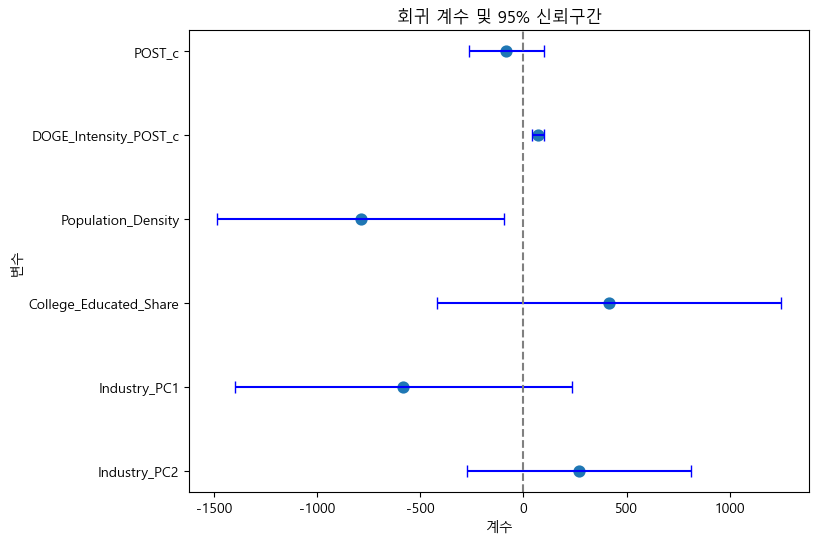

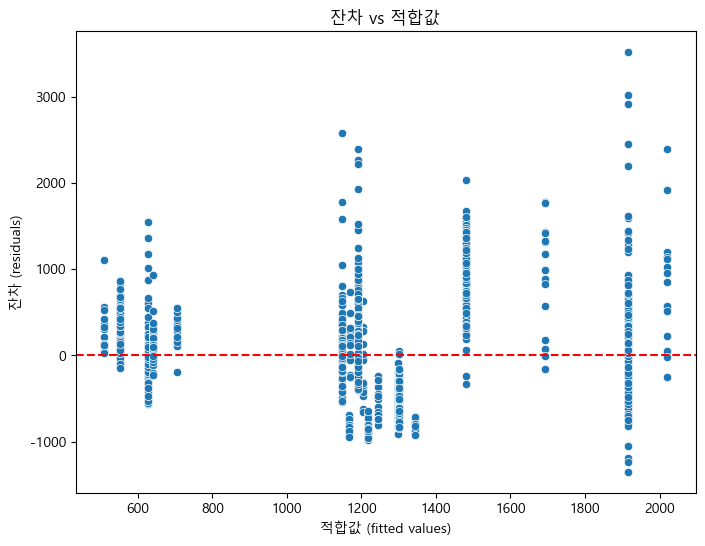

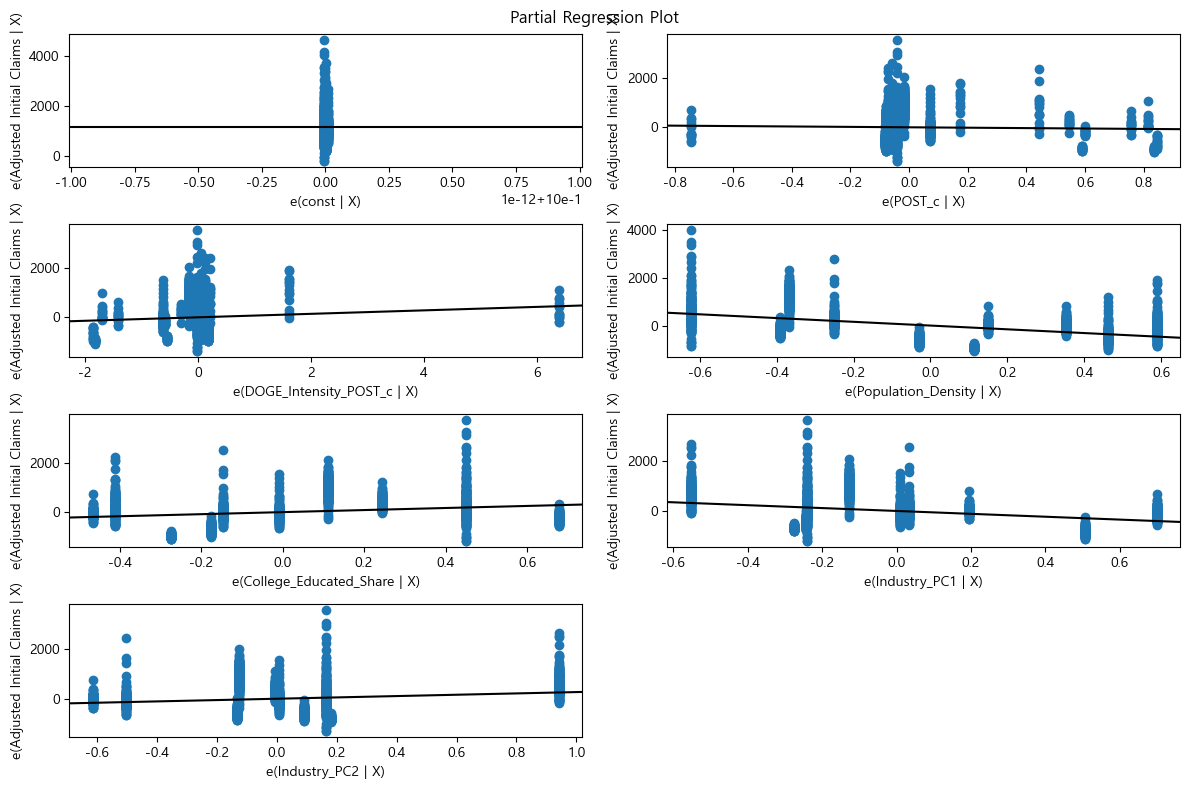

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# 한글 폰트 설정 (예: 맑은고딕, AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows: 'Malgun Gothic', Mac: 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

# (1) 회귀 계수 plot
coef = model_top10.params
conf = model_top10.conf_int()
conf['coef'] = coef
conf.columns = ['2.5%', '97.5%', 'coef']
conf = conf.drop('const')

plt.figure(figsize=(8, 6))
sns.pointplot(x='coef', y=conf.index, data=conf, join=False)
plt.errorbar(conf['coef'], conf.index, 
             xerr=[conf['coef'] - conf['2.5%'], conf['97.5%'] - conf['coef']], 
             fmt='none', c='b', capsize=4)
plt.axvline(x=0, color='grey', linestyle='--')
plt.title('회귀 계수 및 95% 신뢰구간')
plt.xlabel('계수')
plt.ylabel('변수')
plt.show()

# (2) 잔차 plot
residuals = model_top10.resid
fitted = model_top10.fittedvalues

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('잔차 vs 적합값')
plt.xlabel('적합값 (fitted values)')
plt.ylabel('잔차 (residuals)')
plt.show()

# (3) partial regression plot
sm.graphics.plot_partregress_grid(model_top10, fig=plt.figure(figsize=(12, 8)))
plt.show()




In [8]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# District of Columbia만 필터링
df_dc = df_merged[df_merged['State'] == 'District of Columbia']

# 표준화 (필요 시)
scaler = StandardScaler()
to_scale = ['Population_Density', 'College_Educated_Share', 'Industry_PC1', 'Industry_PC2', 'DOGE_Intensity_POST_c']
df_dc.loc[:, to_scale] = scaler.fit_transform(df_dc[to_scale])

# 독립변수 설정
indep_vars = [
    'POST_c',
    'DOGE_Intensity_POST_c',
    'Population_Density',
    'College_Educated_Share',
    'Industry_PC1',
    'Industry_PC2'
]
X = df_dc[indep_vars]
X = sm.add_constant(X)
y = df_dc['Adjusted Initial Claims']
groups = df_dc['State']

# NA 제거
full_data = pd.concat([X, y, groups], axis=1).dropna()
X = full_data[X.columns]
y = full_data['Adjusted Initial Claims']
groups = full_data['State']

# 회귀분석 실행 (데이터 충분한 경우만)
if len(full_data) > len(indep_vars) + 1:
    model_dc = sm.OLS(y, X).fit(cov_type='HC3')  # heteroskedasticity robust SE
    print(model_dc.summary())
else:
    print("District of Columbia 데이터가 부족하여 회귀분석을 실행할 수 없습니다.")



                               OLS Regression Results                              
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.150
Model:                                 OLS   Adj. R-squared:                  0.145
Method:                      Least Squares   F-statistic:                     661.2
Date:                     Sat, 10 May 2025   Prob (F-statistic):           1.78e-60
Time:                             20:21:15   Log-Likelihood:                -1234.2
No. Observations:                      172   AIC:                             2472.
Df Residuals:                          170   BIC:                             2479.
Df Model:                                1                                         
Covariance Type:                       HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\mikey\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [9]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

# District of Columbia만 필터링
df_dc = df_merged[df_merged['State'] == 'District of Columbia'].copy()

# PCA 재계산
industry_cols = [col for col in df_x.columns if col not in ['State', 'Population_Density', 'College_Educated_Share']]
X_industry_dc = df_dc[industry_cols].fillna(0)
pca = PCA(n_components=2)
industry_pca_dc = pca.fit_transform(X_industry_dc)
df_dc['Industry_PC1'] = industry_pca_dc[:, 0]
df_dc['Industry_PC2'] = industry_pca_dc[:, 1]

# 상호작용항 중심화
df_dc['DOGE_Intensity_c'] = df_dc['DOGE_Intensity_WeightedAverage'] - df_dc['DOGE_Intensity_WeightedAverage'].mean()
df_dc['POST_c'] = df_dc['POST'] - df_dc['POST'].mean()
df_dc['DOGE_Intensity_POST_c'] = df_dc['DOGE_Intensity_c'] * df_dc['POST_c']

# 표준화
scaler = StandardScaler()
to_scale = ['Population_Density', 'College_Educated_Share', 'Industry_PC1', 'Industry_PC2', 'DOGE_Intensity_POST_c']
df_dc.loc[:, to_scale] = scaler.fit_transform(df_dc[to_scale])

# 독립변수 설정
indep_vars = ['POST_c', 'DOGE_Intensity_POST_c', 'Population_Density',
              'College_Educated_Share', 'Industry_PC1', 'Industry_PC2']

# 표준편차 거의 0인 변수 제거
stds = df_dc[indep_vars].std()
low_var_cols = stds[stds < 1e-8].index.tolist()
print(f"표준편차 ≈0 제거 변수: {low_var_cols}")
valid_vars = [v for v in indep_vars if v not in low_var_cols]

# VIF 계산
X_check = sm.add_constant(df_dc[valid_vars])
vif_data = pd.DataFrame()
vif_data['feature'] = X_check.columns
vif_data['VIF'] = [variance_inflation_factor(X_check.values, i) for i in range(X_check.shape[1])]
print("\nVIF 결과:")
print(vif_data)

# VIF >10인 변수 제거
high_vif_cols = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
high_vif_cols = [col for col in high_vif_cols if col != 'const']
print(f"\nVIF>10 제거 변수: {high_vif_cols}")
final_vars = [v for v in valid_vars if v not in high_vif_cols]

# 최종 OLS 실행
X = sm.add_constant(df_dc[final_vars])
y = df_dc['Adjusted Initial Claims']
full_data = pd.concat([X, y], axis=1).dropna()
X = full_data[X.columns]
y = full_data['Adjusted Initial Claims']

if len(full_data) > len(final_vars) + 1:
    model_dc = sm.OLS(y, X).fit(cov_type='HC3')
    print("\nOLS 결과:")
    print(model_dc.summary())
else:
    print("\n데이터가 부족하여 회귀분석을 실행할 수 없습니다.")


표준편차 ≈0 제거 변수: ['DOGE_Intensity_POST_c', 'Population_Density', 'College_Educated_Share', 'Industry_PC1']

VIF 결과:
        feature       VIF
0         const  1.000000
1        POST_c  1.000571
2  Industry_PC2  1.000571

VIF>10 제거 변수: []

OLS 결과:
                               OLS Regression Results                              
Dep. Variable:     Adjusted Initial Claims   R-squared:                       0.205
Model:                                 OLS   Adj. R-squared:                  0.195
Method:                      Least Squares   F-statistic:                     10.70
Date:                     Sat, 10 May 2025   Prob (F-statistic):           4.20e-05
Time:                             20:26:36   Log-Likelihood:                -1228.4
No. Observations:                      172   AIC:                             2463.
Df Residuals:                          169   BIC:                             2472.
Df Model:                                2                                         